In [1]:
# ==========================================
# 1. Green AI 实验环境配置
# ==========================================

# CodeCarbon：记录训练过程的能源消耗和碳排放
!pip install codecarbon -q


# --------------------------
# 1.1 导入基础库
# --------------------------

import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from codecarbon import EmissionsTracker


# --------------------------
# 1.2 设置随机种子
# 保证实验结果尽量可以重复
# --------------------------

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


# --------------------------
# 1.3 创建输出目录
# --------------------------

OUTPUT_FOLDER = "green_ai_results"
EMISSIONS_FOLDER = os.path.join(
    OUTPUT_FOLDER,
    "emissions"
)

os.makedirs(
    EMISSIONS_FOLDER,
    exist_ok=True
)


# --------------------------
# 1.4 设置输出文件名称
# --------------------------

RESULTS_FILE = os.path.join(
    OUTPUT_FOLDER,
    "experiment_results.csv"
)

PLOT_FILE = os.path.join(
    OUTPUT_FOLDER,
    "tradeoff_plot.png"
)


# --------------------------
# 1.5 定义四组实验
# --------------------------

EXPERIMENTS = [
    {
        "name": "A_50pct_50epochs",
        "data_fraction": 0.50,
        "epochs": 50
    },
    {
        "name": "B_50pct_100epochs",
        "data_fraction": 0.50,
        "epochs": 100
    },
    {
        "name": "C_100pct_50epochs",
        "data_fraction": 1.00,
        "epochs": 50
    },
    {
        "name": "D_100pct_100epochs",
        "data_fraction": 1.00,
        "epochs": 100
    }
]


# --------------------------
# 1.6 显示运行环境
# --------------------------

print("Green AI environment setup complete.")
print("TensorFlow version:", tf.__version__)
print("Output folder:", OUTPUT_FOLDER)

print("\nAvailable GPU devices:")
print(tf.config.list_physical_devices("GPU"))

print("\nExperiment matrix:")
display(pd.DataFrame(EXPERIMENTS))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.9/388.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 111.7 MB/s eta 0:00:00
Green AI environment setup complete.
TensorFlow version: 2.20.0
Output folder: green_ai_results

Available GPU devices:
[]

Experiment matrix:


,name,data_fraction,epochs
0,A_50pct_50epochs,0.5,50
1,B_50pct_100epochs,0.5,100
2,C_100pct_50epochs,1.0,50
3,D_100pct_100epochs,1.0,100


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Original training images: (60000, 28, 28)
Original training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)

Prepared datasets:
50% training data: (30000, 28, 28) (30000,)
100% training data: (60000, 28, 28) (60000,)
Shared test data: (10000, 28, 28) (10000,)

Class distribution:


,Class,50% Data,100% Data
0,T-shirt/top,3000,6000
1,Trouser,3000,6000
2,Pullover,3000,6000
3,Dress,3000,6000
4,Coat,3000,6000
5,Sandal,3000,6000
6,Shirt,3000,6000
7,Sneaker,3000,6000
8,Bag,3000,6000
9,Ankle boot,3000,6000


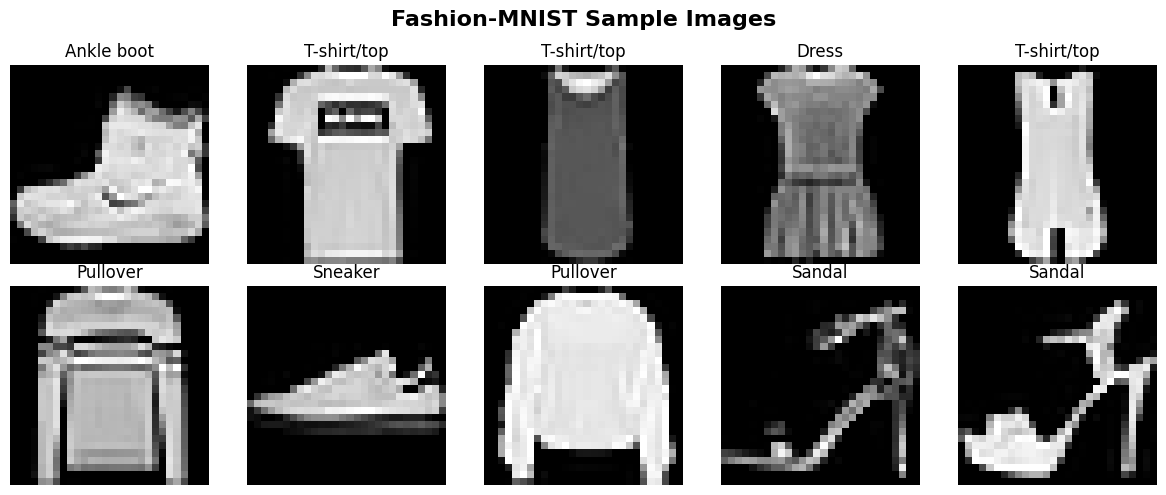

In [2]:
# ==========================================
# 2. 下载并预处理 Fashion-MNIST 数据
# ==========================================

from sklearn.model_selection import train_test_split


# --------------------------
# 2.1 下载数据集
# --------------------------

(
    train_images_full,
    train_labels_full
), (
    test_images,
    test_labels
) = tf.keras.datasets.fashion_mnist.load_data()


print("Original training images:", train_images_full.shape)
print("Original training labels:", train_labels_full.shape)

print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)


# --------------------------
# 2.2 标准化像素
# 原始像素范围：0 至 255
# 新像素范围：0 至 1
# --------------------------

train_images_full = (
    train_images_full.astype("float32") / 255.0
)

test_images = (
    test_images.astype("float32") / 255.0
)


# --------------------------
# 2.3 创建 50% 训练数据
# 使用 stratify 保持各类别比例一致
# --------------------------

(
    train_images_50,
    _,
    train_labels_50,
    _
) = train_test_split(
    train_images_full,
    train_labels_full,
    train_size=0.50,
    random_state=RANDOM_SEED,
    stratify=train_labels_full
)


print("\nPrepared datasets:")
print(
    "50% training data:",
    train_images_50.shape,
    train_labels_50.shape
)

print(
    "100% training data:",
    train_images_full.shape,
    train_labels_full.shape
)

print(
    "Shared test data:",
    test_images.shape,
    test_labels.shape
)


# --------------------------
# 2.4 定义 Fashion-MNIST 类别名称
# --------------------------

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


# --------------------------
# 2.5 检查类别分布
# --------------------------

distribution_50 = pd.Series(
    train_labels_50
).value_counts().sort_index()

distribution_100 = pd.Series(
    train_labels_full
).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Class": CLASS_NAMES,
    "50% Data": distribution_50.values,
    "100% Data": distribution_100.values
})

print("\nClass distribution:")
display(class_distribution)


# --------------------------
# 2.6 显示部分训练图片
# --------------------------

plt.figure(figsize=(12, 5))

for image_index in range(10):
    plt.subplot(2, 5, image_index + 1)

    plt.imshow(
        train_images_full[image_index],
        cmap="gray"
    )

    plt.title(
        CLASS_NAMES[
            train_labels_full[image_index]
        ]
    )

    plt.axis("off")

plt.suptitle(
    "Fashion-MNIST Sample Images",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [3]:
# ==========================================
# 3. 建立深度 MLP 模型
# ==========================================

def build_deep_mlp():
    """
    每次调用都创建一个全新的深度 MLP 模型。

    模型结构：
    - 1 个 Flatten 层
    - 5 个 Dense 隐藏层
    - 1 个输出层
    """

    model = models.Sequential(
        [
            # 输入为 28 × 28 的灰度图片
            layers.Input(
                shape=(28, 28),
                name="input_image"
            ),

            # 将二维图片转换成一维向量
            layers.Flatten(
                name="flatten"
            ),

            # 第 1 个隐藏层
            layers.Dense(
                256,
                activation="relu",
                name="dense_1"
            ),

            # 第 2 个隐藏层
            layers.Dense(
                128,
                activation="relu",
                name="dense_2"
            ),

            # 第 3 个隐藏层
            layers.Dense(
                64,
                activation="relu",
                name="dense_3"
            ),

            # 第 4 个隐藏层
            layers.Dense(
                32,
                activation="relu",
                name="dense_4"
            ),

            # 第 5 个隐藏层
            layers.Dense(
                16,
                activation="relu",
                name="dense_5"
            ),

            # Fashion-MNIST 有 10 个类别
            layers.Dense(
                10,
                activation="softmax",
                name="output"
            )
        ],
        name="green_ai_deep_mlp"
    )


    # 配置模型训练方法
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# --------------------------
# 3.1 创建一个模型用于检查结构
# --------------------------

preview_model = build_deep_mlp()


# --------------------------
# 3.2 显示模型结构
# --------------------------

preview_model.summary()


# --------------------------
# 3.3 验证隐藏 Dense 层数量
# --------------------------

dense_layers = [
    layer
    for layer in preview_model.layers
    if isinstance(layer, layers.Dense)
]

# 最后一个 Dense 是输出层，因此隐藏层数量减 1
hidden_dense_count = len(dense_layers) - 1

print("\nHidden Dense layers:", hidden_dense_count)
print("Output classes:", preview_model.output_shape[-1])

assert hidden_dense_count >= 5, (
    "The model must contain at least "
    "five hidden Dense layers."
)

print(
    "\nModel architecture meets "
    "the assignment requirement."
)

Model: "green_ai_deep_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,890 (956.60 KB)

 Trainable params: 244,890 (956.60 KB)

 Non-trainable params: 0 (0.00 B)


Hidden Dense layers: 5
Output classes: 10

Model architecture meets the assignment requirement.


In [4]:
# ==========================================
# 4. 定义单次 Green AI 实验函数
# ==========================================

def run_green_ai_experiment(
    experiment_name,
    data_fraction,
    epochs
):
    """
    运行一次完整的 Green AI 实验。

    记录内容：
    - 使用的数据比例
    - 训练样本数量
    - Epoch 数量
    - 训练时间
    - 测试准确率
    - 能源消耗与碳排放
    """

    print("\n" + "=" * 65)
    print(f"Starting experiment: {experiment_name}")
    print(f"Data fraction: {data_fraction:.0%}")
    print(f"Maximum epochs: {epochs}")
    print("=" * 65)


    # --------------------------
    # 4.1 选择训练数据
    # --------------------------

    if data_fraction == 0.50:
        experiment_images = train_images_50
        experiment_labels = train_labels_50

    elif data_fraction == 1.00:
        experiment_images = train_images_full
        experiment_labels = train_labels_full

    else:
        raise ValueError(
            "data_fraction must be 0.50 or 1.00"
        )


    # --------------------------
    # 4.2 清理上一次模型
    # --------------------------

    tf.keras.backend.clear_session()

    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)


    # 每次实验必须创建全新的模型
    model = build_deep_mlp()


    # --------------------------
    # 4.3 配置 CodeCarbon
    # --------------------------

    emissions_file = (
        f"{experiment_name}_emissions.csv"
    )

    tracker = EmissionsTracker(
        project_name=experiment_name,
        output_dir=EMISSIONS_FOLDER,
        output_file=emissions_file,
        measure_power_secs=1,
        log_level="error"
    )


    # --------------------------
    # 4.4 开始记录并训练模型
    # --------------------------

    tracker.start()
    training_start_time = time.time()

    try:
        history = model.fit(
            experiment_images,
            experiment_labels,

            # 使用 10% 训练数据进行验证
            validation_split=0.10,

            epochs=epochs,
            batch_size=128,

            # 训练时打乱数据
            shuffle=True,

            # 显示每个 epoch 的训练结果
            verbose=1
        )

    finally:
        training_end_time = time.time()

        # stop() 返回的单位是 kg CO₂
        emissions_kg = tracker.stop()


    # --------------------------
    # 4.5 在统一测试集上评估
    # --------------------------

    test_loss, test_accuracy = model.evaluate(
        test_images,
        test_labels,
        verbose=0
    )


    # --------------------------
    # 4.6 计算实验指标
    # --------------------------

    training_seconds = (
        training_end_time - training_start_time
    )

    emissions_grams = emissions_kg * 1000

    completed_epochs = len(
        history.history["loss"]
    )


    # --------------------------
    # 4.7 整理实验结果
    # --------------------------

    result = {
        "Experiment": experiment_name,
        "Data Fraction": data_fraction,
        "Data Percentage": data_fraction * 100,
        "Training Samples": len(experiment_images),
        "Planned Epochs": epochs,
        "Completed Epochs": completed_epochs,
        "Batch Size": 128,
        "Training Time Seconds": training_seconds,
        "Test Loss": test_loss,
        "Test Accuracy": test_accuracy,
        "Test Accuracy Percentage": (
            test_accuracy * 100
        ),
        "CO2 Emissions Kg": emissions_kg,
        "CO2 Emissions Grams": emissions_grams
    }


    # --------------------------
    # 4.8 输出实验结果
    # --------------------------

    print("\nExperiment completed:")
    print(
        f"Test accuracy: "
        f"{test_accuracy * 100:.2f}%"
    )

    print(
        f"Training time: "
        f"{training_seconds:.2f} seconds"
    )

    print(
        f"CO2 emissions: "
        f"{emissions_grams:.6f} grams"
    )

    print(
        f"CodeCarbon file: "
        f"{EMISSIONS_FOLDER}/"
        f"{emissions_file}"
    )


    # 不保存四个模型，任务重点是比较资源效率
    del model

    return result, history


print(
    "Green AI experiment function "
    "created successfully."
)

Green AI experiment function created successfully.


In [5]:
# ==========================================
# 5. 执行四组 Green AI 实验
# ==========================================

all_results = []
all_histories = {}


# --------------------------
# 5.1 依次运行四组实验
# --------------------------

for experiment_config in EXPERIMENTS:

    experiment_name = experiment_config["name"]
    data_fraction = experiment_config["data_fraction"]
    epochs = experiment_config["epochs"]

    result, history = run_green_ai_experiment(
        experiment_name=experiment_name,
        data_fraction=data_fraction,
        epochs=epochs
    )

    # 保存实验结果
    all_results.append(result)

    # 保存训练历史，用于后续绘图
    all_histories[experiment_name] = (
        history.history
    )


    # --------------------------
    # 每完成一组就立即保存
    # 防止 Colab 中断后结果丢失
    # --------------------------

    checkpoint_df = pd.DataFrame(
        all_results
    )

    checkpoint_df.to_csv(
        RESULTS_FILE,
        index=False
    )

    checkpoint_df.to_csv(
        os.path.join(
            OUTPUT_FOLDER,
            "emissions.csv"
        ),
        index=False
    )

    print(
        f"\nCheckpoint saved after "
        f"{experiment_name}"
    )


# --------------------------
# 5.2 创建最终结果表
# --------------------------

results_df = pd.DataFrame(
    all_results
)


# --------------------------
# 5.3 保存完整实验结果
# --------------------------

results_df.to_csv(
    RESULTS_FILE,
    index=False
)

results_df.to_csv(
    os.path.join(
        OUTPUT_FOLDER,
        "emissions.csv"
    ),
    index=False
)


# --------------------------
# 5.4 显示关键指标
# --------------------------

comparison_columns = [
    "Experiment",
    "Data Percentage",
    "Training Samples",
    "Completed Epochs",
    "Training Time Seconds",
    "Test Accuracy Percentage",
    "CO2 Emissions Grams"
]

print("\n" + "=" * 70)
print("ALL FOUR EXPERIMENTS COMPLETED")
print("=" * 70)

display(
    results_df[
        comparison_columns
    ].round(6)
)


print("\nSaved result files:")
print(RESULTS_FILE)

print(
    os.path.join(
        OUTPUT_FOLDER,
        "emissions.csv"
    )
)


Starting experiment: A_50pct_50epochs
Data fraction: 50%
Maximum epochs: 50


[codecarbon WARNING @ 21:55:05] Multiple instances of codecarbon are allowed to run at the same time.


Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7325 - loss: 0.7601 - val_accuracy: 0.8197 - val_loss: 0.5248
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8354 - loss: 0.4626 - val_accuracy: 0.8397 - val_loss: 0.4434
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8530 - loss: 0.4059 - val_accuracy: 0.8470 - val_loss: 0.4242
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8663 - loss: 0.3679 - val_accuracy: 0.8543 - val_loss: 0.4067
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8756 - loss: 0.3406 - val_accuracy: 0.8570 - val_loss: 0.3960
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8822 - loss: 0.3199 - val_accuracy: 0.8647 - val_loss: 0.3805
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8891 - loss: 0.3008 - val_accuracy: 0.8610 - val_loss: 0.3967
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8911 - loss: 0.2920 - val_accuracy: 0.

,Experiment,Data Percentage,Training Samples,Completed Epochs,Training Time Seconds,Test Accuracy Percentage,CO2 Emissions Grams
0,A_50pct_50epochs,50.0,30000,50,63.306953,86.949998,1.832962
1,B_50pct_100epochs,50.0,30000,100,124.099151,87.260002,3.128156
2,C_100pct_50epochs,100.0,60000,50,130.919887,88.550001,3.664331
3,D_100pct_100epochs,100.0,60000,100,256.506113,88.540000,7.088275



Saved result files:
green_ai_results/experiment_results.csv
green_ai_results/emissions.csv


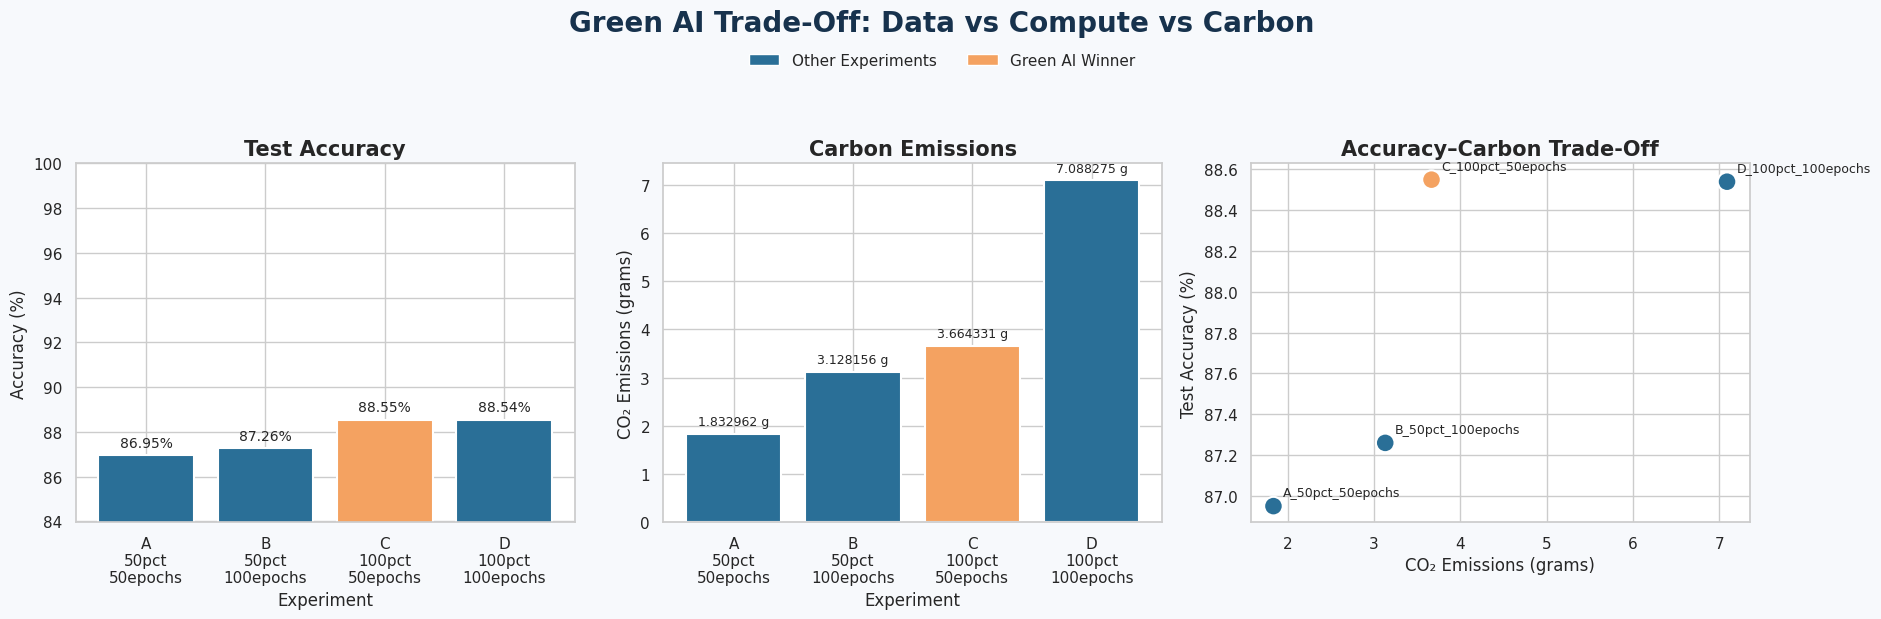


GREEN AI WINNER
Experiment: C_100pct_50epochs
Data percentage: 100%
Epochs: 50
Test accuracy: 88.55%
CO2 emissions: 3.664331 grams
Training time: 130.92 seconds

Selection rule: among experiments within 1 percentage point of the highest accuracy, select the one with the lowest carbon emissions.

Plot saved as:
green_ai_results/tradeoff_plot.png


In [6]:
# ==========================================
# 6. 分析结果并制作 Green AI 对比图
# ==========================================

# 如果 Colab 中的 results_df 不存在，
# 就从已经保存的 CSV 中重新读取
if "results_df" not in globals():
    results_df = pd.read_csv(
        RESULTS_FILE
    )


# --------------------------
# 6.1 Green AI 模型选择规则
# --------------------------
# 先找到最高测试准确率。
# 准确率与最高值相差不超过 1 个百分点的实验，
# 被认为具有相近的预测性能。
# 在这些实验中选择碳排放最低的配置。

highest_accuracy = results_df[
    "Test Accuracy Percentage"
].max()

accuracy_tolerance = 1.0

green_candidates = results_df[
    results_df["Test Accuracy Percentage"]
    >= highest_accuracy - accuracy_tolerance
].copy()

winner_index = green_candidates[
    "CO2 Emissions Grams"
].idxmin()

winner = results_df.loc[
    winner_index
].copy()


# 标记最终获胜实验
results_df["Green AI Winner"] = False

results_df.loc[
    winner_index,
    "Green AI Winner"
] = True


# --------------------------
# 6.2 设置专业图表风格
# --------------------------

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

experiment_labels = results_df[
    "Experiment"
].str.replace(
    "_",
    "\n",
    regex=False
)

default_color = "#2A6F97"
winner_color = "#F4A261"

bar_colors = [
    winner_color if is_winner else default_color
    for is_winner
    in results_df["Green AI Winner"]
]


# --------------------------
# 6.3 创建三个对比图
# --------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 6)
)

fig.patch.set_facecolor("#F7F9FC")


# 图 1：测试准确率
accuracy_bars = axes[0].bar(
    experiment_labels,
    results_df[
        "Test Accuracy Percentage"
    ],
    color=bar_colors,
    edgecolor="white",
    linewidth=1.5
)

axes[0].set_title(
    "Test Accuracy",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel("Experiment")
axes[0].set_ylabel("Accuracy (%)")

accuracy_minimum = max(
    0,
    results_df[
        "Test Accuracy Percentage"
    ].min() - 3
)

axes[0].set_ylim(
    accuracy_minimum,
    100
)

axes[0].bar_label(
    accuracy_bars,
    fmt="%.2f%%",
    padding=4,
    fontsize=10
)


# 图 2：碳排放
emission_bars = axes[1].bar(
    experiment_labels,
    results_df[
        "CO2 Emissions Grams"
    ],
    color=bar_colors,
    edgecolor="white",
    linewidth=1.5
)

axes[1].set_title(
    "Carbon Emissions",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_xlabel("Experiment")
axes[1].set_ylabel("CO₂ Emissions (grams)")

axes[1].bar_label(
    emission_bars,
    fmt="%.6f g",
    padding=4,
    fontsize=9
)


# 图 3：准确率和排放的权衡关系
axes[2].scatter(
    results_df[
        "CO2 Emissions Grams"
    ],
    results_df[
        "Test Accuracy Percentage"
    ],
    s=180,
    c=bar_colors,
    edgecolor="white",
    linewidth=1.5
)

for _, experiment_row in results_df.iterrows():

    axes[2].annotate(
        experiment_row["Experiment"],
        (
            experiment_row[
                "CO2 Emissions Grams"
            ],
            experiment_row[
                "Test Accuracy Percentage"
            ]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9
    )

axes[2].set_title(
    "Accuracy–Carbon Trade-Off",
    fontsize=15,
    fontweight="bold"
)

axes[2].set_xlabel(
    "CO₂ Emissions (grams)"
)

axes[2].set_ylabel(
    "Test Accuracy (%)"
)


# --------------------------
# 6.4 添加总标题和图例
# --------------------------

fig.suptitle(
    "Green AI Trade-Off: "
    "Data vs Compute vs Carbon",
    fontsize=20,
    fontweight="bold",
    color="#17324D",
    y=1.03
)

from matplotlib.patches import Patch

legend_items = [
    Patch(
        facecolor=default_color,
        label="Other Experiments"
    ),
    Patch(
        facecolor=winner_color,
        label="Green AI Winner"
    )
]

fig.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=False
)

plt.tight_layout(
    rect=[0, 0, 1, 0.92]
)


# --------------------------
# 6.5 保存并显示图表
# --------------------------

plt.savefig(
    PLOT_FILE,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()


# --------------------------
# 6.6 保存带有获胜标记的结果
# --------------------------

results_df.to_csv(
    RESULTS_FILE,
    index=False
)

results_df.to_csv(
    os.path.join(
        OUTPUT_FOLDER,
        "emissions.csv"
    ),
    index=False
)


# --------------------------
# 6.7 输出最终选择
# --------------------------

print("\n" + "=" * 70)
print("GREEN AI WINNER")
print("=" * 70)

print(
    "Experiment:",
    winner["Experiment"]
)

print(
    "Data percentage:",
    f'{winner["Data Percentage"]:.0f}%'
)

print(
    "Epochs:",
    int(winner["Completed Epochs"])
)

print(
    "Test accuracy:",
    f'{winner["Test Accuracy Percentage"]:.2f}%'
)

print(
    "CO2 emissions:",
    f'{winner["CO2 Emissions Grams"]:.6f} grams'
)

print(
    "Training time:",
    f'{winner["Training Time Seconds"]:.2f} seconds'
)

print(
    "\nSelection rule: among experiments "
    "within 1 percentage point of the "
    "highest accuracy, select the one "
    "with the lowest carbon emissions."
)

print("\nPlot saved as:")
print(PLOT_FILE)